# Baseline Evaluation: Small Models on Cross-Model Verified Dataset

This notebook evaluates small/medium LLMs on the cross-model verified dataset
as a **pre-fine-tuning baseline**.

**Pipeline:**
1. Load cross-model verified Q&A dataset
2. For each model, generate answers to questions
3. Use Gemini Flash to extract final answer from model response
4. Compare extracted answer to ground truth
5. Analyze results across models

## Setup and Imports

In [1]:
import json
import re
import sys
from pathlib import Path
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass, field
from openai import OpenAI
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
import time

sys.path.insert(0, '..')
from utils.api_client import create_openrouter_client
from utils.data_io import load_dataset as _load_dataset

# Initialize OpenRouter client
client = create_openrouter_client()

# Token tracking
total_tokens = {}
token_lock = threading.Lock()

## Configuration

In [2]:
@dataclass
class EvalConfig:
    """Evaluation configuration"""
    # Dataset -- cross-model verified
    dataset_path: str = "../data/cross_model_verified.jsonl"
    output_dir: str = "../results/baseline_small_models"

    # Models to evaluate
    models: List[str] = field(default_factory=lambda: [
        "qwen/qwen3-32b",
        "deepseek/deepseek-r1-0528-qwen3-8b",
        "google/gemma-3-27b-it",
    ])

    # Answer extractor model (fast and cheap)
    extractor_model: str = "google/gemini-2.5-flash"

    # Evaluation settings
    sample_size: Optional[int] = None  # None = use all
    max_workers: int = 5
    temperature: float = 0.1
    max_tokens: int = 2000


config = EvalConfig()
Path(config.output_dir).mkdir(parents=True, exist_ok=True)

print(f"Configuration:")
print(f"  Dataset: {config.dataset_path}")
print(f"  Output:  {config.output_dir}")
print(f"  Models to evaluate: {len(config.models)}")
for model in config.models:
    print(f"    - {model}")
print(f"  Answer extractor: {config.extractor_model}")
print(f"  Sample size: {config.sample_size or 'All'}")

Configuration:
  Dataset: ../data/cross_model_verified.jsonl
  Output:  ../results/baseline_small_models
  Models to evaluate: 3
    - qwen/qwen3-32b
    - deepseek/deepseek-r1-0528-qwen3-8b
    - google/gemma-3-27b-it
  Answer extractor: google/gemini-2.5-flash
  Sample size: All


## Load Dataset

In [3]:
def load_dataset(config: EvalConfig) -> List[Dict]:
    """Load the Q&A dataset, with optional sampling."""
    dataset = _load_dataset(config.dataset_path)

    # Sample if specified
    if config.sample_size and config.sample_size < len(dataset):
        import random
        random.seed(42)  # Reproducible sampling
        dataset = random.sample(dataset, config.sample_size)
        print(f"Sampled {config.sample_size} questions from dataset")

    print(f"Loaded {len(dataset)} Q&A pairs")

    # Show sample
    if dataset:
        print(f"\nSample question:")
        print(f"  Source: {dataset[0].get('source', 'N/A')}")
        print(f"  Question: {dataset[0]['question'][:150]}...")
        print(f"  Ground truth answer: {dataset[0]['answer']}")

    return dataset


dataset = load_dataset(config)

Loaded 30 Q&A pairs

Sample question:
  Source: cross_model_verified
  Question: A software development team is tracking defects in two different modules of their application. Module A has 50,000 lines of code and Module B has 75,0...
  Ground truth answer: (a) Module A: 0.36 defects/KLOC, Module B: 0.467 defects/KLOC
(b) Module A: (0.233, 0.534), Module B: (0.345, 0.604)
(c) Fail to reject H₀; no significant difference (LRT = 0.816, p-value = 0.366)


## Evaluation Prompt

In [4]:
EVALUATION_PROMPT = """You are an expert in reliability engineering, probability theory, and system analysis. 

A student has asked you the following question. Provide a clear, accurate answer.

IMPORTANT INSTRUCTIONS:
1. Read the question carefully and identify what is being asked
2. Show your reasoning step-by-step
3. Perform any necessary calculations accurately
4. At the end, clearly state your FINAL ANSWER
5. For multi-part questions (a, b, c, etc.), provide ALL answers
6. Format your final answer clearly - use numbers, comma-separated values, or True/False as appropriate

Question:
{question}

Please solve this problem step-by-step and provide your final answer."""


def format_prompt(question: str) -> str:
    """Format the evaluation prompt with a question"""
    return EVALUATION_PROMPT.format(question=question)


if dataset:
    print("Sample prompt (first 300 chars):")
    print("="*80)
    print(format_prompt(dataset[0]['question'])[:300] + "...")
    print("="*80)

Sample prompt (first 300 chars):
You are an expert in reliability engineering, probability theory, and system analysis. 

A student has asked you the following question. Provide a clear, accurate answer.

IMPORTANT INSTRUCTIONS:
1. Read the question carefully and identify what is being asked
2. Show your reasoning step-by-step
3. P...


## Answer Extraction with Gemini Flash

In [5]:
EXTRACTION_PROMPT = """You are extracting the final answer from a model's response to a reliability engineering question.

The model may have provided reasoning, calculations, or thinking. Your job is to extract ONLY the final answer.

EXTRACTION RULES:
1. Look for phrases like "final answer", "the answer is", "therefore", "result"
2. Extract the numerical value(s), boolean (True/False), or expression
3. For multi-part answers, provide comma-separated values
4. Remove units, explanations, and extra text
5. If multiple numbers are given, extract all of them comma-separated
6. If no clear answer exists, respond with: "UNABLE_TO_EXTRACT"

EXAMPLES:
Model response: "After calculating, the reliability is 0.95 and the MTTF is 1000 hours."
Your extraction: "0.95, 1000"

Model response: "The system will fail, so the answer is False."
Your extraction: "False"

Model response: "Therefore, the final answer is approximately 0.8413."
Your extraction: "0.8413"

ORIGINAL QUESTION:
{question}

MODEL'S RESPONSE:
{model_response}

Extract ONLY the final answer (no explanation):"""


def extract_answer(question: str, model_response: str, config: EvalConfig) -> str:
    """Use Gemini Flash to extract the final answer from model response"""
    prompt = EXTRACTION_PROMPT.format(
        question=question,
        model_response=model_response
    )

    try:
        response = client.chat.completions.create(
            model=config.extractor_model,
            max_tokens=200,
            temperature=0.1,
            timeout=180,
            messages=[{"role": "user", "content": prompt}]
        )

        global total_tokens
        with token_lock:
            if config.extractor_model not in total_tokens:
                total_tokens[config.extractor_model] = 0
            total_tokens[config.extractor_model] += (
                response.usage.prompt_tokens + response.usage.completion_tokens
            )

        return response.choices[0].message.content.strip()

    except Exception as e:
        print(f"Extraction error: {e}")
        return "EXTRACTION_ERROR"

## Comparison and Evaluation Functions

In [6]:
def call_model(model: str, question: str, config: EvalConfig) -> str:
    """Call a model with the question and return its response"""
    prompt = format_prompt(question)

    try:
        response = client.chat.completions.create(
            model=model,
            max_tokens=config.max_tokens,
            temperature=config.temperature,
            timeout=180,
            messages=[{"role": "user", "content": prompt}]
        )

        global total_tokens
        with token_lock:
            if model not in total_tokens:
                total_tokens[model] = 0
            total_tokens[model] += (
                response.usage.prompt_tokens + response.usage.completion_tokens
            )

        return response.choices[0].message.content

    except Exception as e:
        print(f"Error calling {model}: {e}")
        return f"ERROR: {str(e)}"


def normalize_answer(answer: str) -> str:
    """Normalize answer for comparison"""
    answer = answer.lower().strip()
    answer = answer.replace(" ", "")
    answer = answer.replace("\u00d7", "x")
    answer = answer.replace("^", "**")
    return answer


def compare_answers(predicted: str, ground_truth: str) -> Dict:
    """Compare predicted answer with ground truth"""
    pred_norm = normalize_answer(predicted)
    truth_norm = normalize_answer(ground_truth)

    # Exact match
    exact_match = pred_norm == truth_norm

    # Numerical match
    pred_numbers = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', predicted)
    truth_numbers = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', ground_truth)

    numerical_match = False
    if pred_numbers and truth_numbers:
        try:
            pred_nums = [float(x) for x in pred_numbers]
            truth_nums = [float(x) for x in truth_numbers]

            if len(pred_nums) == len(truth_nums):
                matches = [
                    abs(p - t) / max(abs(t), 1e-10) < 0.05
                    for p, t in zip(pred_nums, truth_nums)
                ]
                numerical_match = all(matches)
        except:
            pass

    # Partial match
    partial_match = truth_norm in pred_norm or pred_norm in truth_norm

    return {
        'exact_match': exact_match,
        'numerical_match': numerical_match,
        'partial_match': partial_match,
        'correct': exact_match or numerical_match or (partial_match and len(truth_norm) > 3)
    }


def evaluate_single_question(item: Dict, model: str, config: EvalConfig) -> Dict:
    """Evaluate a single question with a model"""
    question = item['question']
    ground_truth = item['answer']

    model_response = call_model(model, question, config)
    extracted_answer = extract_answer(question, model_response, config)
    comparison = compare_answers(extracted_answer, ground_truth)

    return {
        'source': item.get('source', 'unknown'),
        'question': question,
        'ground_truth': ground_truth,
        'model_response': model_response,
        'extracted_answer': extracted_answer,
        **comparison
    }


print("Evaluation functions defined.")

Evaluation functions defined.


## Run Evaluation (Parallel)

In [7]:
def evaluate_model(model: str, dataset: List[Dict], config: EvalConfig) -> List[Dict]:
    """Evaluate a single model on the entire dataset (with parallelization)"""
    print(f"\n{'='*80}")
    print(f"Evaluating: {model}")
    print(f"{'='*80}")

    results = []

    with ThreadPoolExecutor(max_workers=config.max_workers) as executor:
        future_to_item = {
            executor.submit(evaluate_single_question, item, model, config): item
            for item in dataset
        }

        for future in tqdm(
            as_completed(future_to_item),
            total=len(dataset),
            desc=f"Evaluating {model.split('/')[-1]}"
        ):
            try:
                result = future.result()
                results.append(result)
            except Exception as e:
                item = future_to_item[future]
                print(f"Error on {item.get('source', '?')}: {e}")

    correct_count = sum(1 for r in results if r['correct'])
    exact_match_count = sum(1 for r in results if r['exact_match'])
    numerical_match_count = sum(1 for r in results if r['numerical_match'])

    print(f"\nResults for {model}:")
    print(f"  Correct: {correct_count}/{len(results)} ({correct_count/len(results)*100:.1f}%)")
    print(f"  Exact match: {exact_match_count}/{len(results)} ({exact_match_count/len(results)*100:.1f}%)")
    print(f"  Numerical match: {numerical_match_count}/{len(results)} ({numerical_match_count/len(results)*100:.1f}%)")
    print(f"  Tokens used: {total_tokens.get(model, 0):,}")

    return results


def evaluate_all_models(dataset: List[Dict], config: EvalConfig) -> Dict[str, List[Dict]]:
    """Evaluate all models on the dataset"""
    all_results = {}

    print(f"\n{'='*80}")
    print(f"STARTING BASELINE EVALUATION")
    print(f"{'='*80}")
    print(f"Dataset size: {len(dataset)}")
    print(f"Models: {len(config.models)}")
    print(f"Total evaluations: {len(dataset) * len(config.models)}")

    start_time = time.time()

    for model in config.models:
        all_results[model] = evaluate_model(model, dataset, config)

        # Save intermediate results
        model_name = model.replace('/', '_')
        output_file = Path(config.output_dir) / f"{model_name}_results.json"
        with open(output_file, 'w', encoding='utf-8') as f:
            json.dump(all_results[model], f, indent=2, ensure_ascii=False)
        print(f"  Saved to: {output_file}")

    elapsed = time.time() - start_time

    print(f"\n{'='*80}")
    print(f"EVALUATION COMPLETE")
    print(f"{'='*80}")
    print(f"Total time: {elapsed/60:.1f} minutes")
    print(f"Avg time per question: {elapsed/len(dataset):.1f} seconds")

    return all_results


# RUN THE EVALUATION
all_results = evaluate_all_models(dataset, config)


STARTING BASELINE EVALUATION
Dataset size: 30
Models: 3
Total evaluations: 90

Evaluating: qwen/qwen3-32b


Evaluating qwen3-32b:   0%|          | 0/30 [00:00<?, ?it/s]

Evaluating qwen3-32b:  47%|████▋     | 14/30 [03:39<02:59, 11.20s/it]

Error calling qwen/qwen3-32b: Expecting value: line 153 column 1 (char 836)


Evaluating qwen3-32b: 100%|██████████| 30/30 [08:29<00:00, 17.00s/it]


...

Error calling deepseek/deepseek-r1-0528-qwen3-8b: Error code: 404 - {'error': {'message': 'No endpoints found for deepseek/deepseek-r1-0528-qwen3-8b.', 'code': 404}, 'user_id': 'user_33cExNCP34NsRyfCOeN4VC5PdFY'}
Error calling deepseek/deepseek-r1-0528-qwen3-8b: Error code: 404 - {'error': {'message': 'No endpoints found for deepseek/deepseek-r1-0528-qwen3-8b.', 'code': 404}, 'user_id': 'user_33cExNCP34NsRyfCOeN4VC5PdFY'}


Evaluating deepseek-r1-0528-qwen3-8b: 100%|██████████| 30/30 [00:02<00:00, 10.06it/s]



Results for deepseek/deepseek-r1-0528-qwen3-8b:
  Correct: 0/30 (0.0%)
  Exact match: 0/30 (0.0%)
  Numerical match: 0/30 (0.0%)
  Tokens used: 0
  Saved to: ..\results\baseline_small_models\deepseek_deepseek-r1-0528-qwen3-8b_results.json

Evaluating: google/gemma-3-27b-it


Evaluating gemma-3-27b-it: 100%|██████████| 30/30 [03:36<00:00,  7.21s/it]


Results for google/gemma-3-27b-it:
  Correct: 4/30 (13.3%)
  Exact match: 0/30 (0.0%)
  Numerical match: 4/30 (13.3%)
  Tokens used: 40,648
  Saved to: ..\results\baseline_small_models\google_gemma-3-27b-it_results.json

EVALUATION COMPLETE
Total time: 12.2 minutes
Avg time per question: 24.3 seconds


## Summary Table

In [8]:
def create_summary_dataframe(all_results: Dict[str, List[Dict]]) -> pd.DataFrame:
    """Create summary statistics for all models"""
    summary_data = []

    for model, results in all_results.items():
        model_short = model.split('/')[-1]
        n = len(results)

        summary_data.append({
            'Model': model_short,
            'Correct': sum(1 for r in results if r['correct']),
            'Exact Match': sum(1 for r in results if r['exact_match']),
            'Numerical Match': sum(1 for r in results if r['numerical_match']),
            'Partial Match': sum(1 for r in results if r['partial_match']),
            'Total': n,
            'Accuracy (%)': sum(1 for r in results if r['correct']) / n * 100 if n else 0,
            'Tokens': total_tokens.get(model, 0)
        })

    return pd.DataFrame(summary_data)


summary_df = create_summary_dataframe(all_results)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(summary_df.to_string(index=False))

summary_df.to_csv(Path(config.output_dir) / "model_comparison.csv", index=False)
print(f"\nSaved to: {config.output_dir}/model_comparison.csv")


MODEL COMPARISON
                    Model  Correct  Exact Match  Numerical Match  Partial Match  Total  Accuracy (%)  Tokens
                qwen3-32b        3            0                3              0     30     10.000000   63116
deepseek-r1-0528-qwen3-8b        0            0                0              0     30      0.000000       0
           gemma-3-27b-it        4            0                4              1     30     13.333333   40648

Saved to: ../results/baseline_small_models/model_comparison.csv


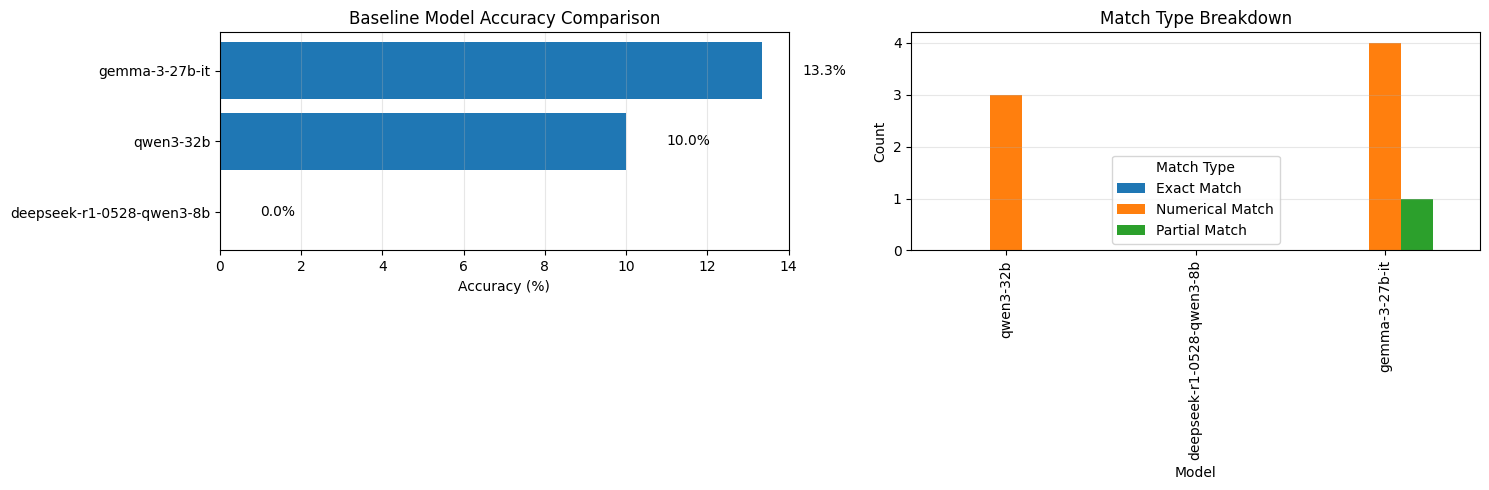


Saved plot to: ../results/baseline_small_models/model_comparison.png


In [9]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Accuracy comparison
summary_df_sorted = summary_df.sort_values('Accuracy (%)', ascending=True)
axes[0].barh(summary_df_sorted['Model'], summary_df_sorted['Accuracy (%)'])
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_title('Baseline Model Accuracy Comparison')
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(summary_df_sorted['Accuracy (%)']):
    axes[0].text(v + 1, i, f'{v:.1f}%', va='center')

# Plot 2: Match type breakdown
match_data = summary_df[['Model', 'Exact Match', 'Numerical Match', 'Partial Match']].set_index('Model')
match_data.plot(kind='bar', ax=axes[1], stacked=False)
axes[1].set_ylabel('Count')
axes[1].set_title('Match Type Breakdown')
axes[1].legend(title='Match Type')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(Path(config.output_dir) / "model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved plot to: {config.output_dir}/model_comparison.png")

## Error Analysis

In [10]:
def analyze_errors(all_results: Dict[str, List[Dict]], n_examples: int = 5):
    """Show examples of incorrect answers for each model"""

    for model, results in all_results.items():
        model_short = model.split('/')[-1]
        incorrect = [r for r in results if not r['correct']]

        if not incorrect:
            print(f"\n{model_short}: No errors!")
            continue

        print(f"\n{'='*80}")
        print(f"{model_short}: {len(incorrect)} errors")
        print(f"{'='*80}")

        for i, error in enumerate(incorrect[:n_examples], 1):
            print(f"\nError {i}:")
            print(f"  Source: {error['source']}")
            print(f"  Question: {error['question'][:150]}...")
            print(f"  Ground truth: {error['ground_truth']}")
            print(f"  Extracted answer: {error['extracted_answer']}")
            print(f"  Model response: {error['model_response'][:200]}...")


analyze_errors(all_results, n_examples=3)


qwen3-32b: 27 errors

Error 1:
  Source: cross_model_verified
  Question: A radar system consists of a critical power amplifier component that fails according to a Weibull distribution with shape parameter β = 1.5 and charac...
  Ground truth: 3 spare amplifiers.
  Extracted answer: UNABLE_TO_EXTRACT
  Model response: ...

Error 2:
  Source: cross_model_verified
  Question: A data center has 5 independent cooling units arranged in a k-out-of-n configuration where at least 3 units must be operational for the system to func...
  Ground truth: 0.924 (or 92.4%)
  Extracted answer: 0.9999999999999999
  Model response: ...

Error 3:
  Source: cross_model_verified
  Question: A critical aerospace component follows a Weibull distribution for its failure time. The characteristic life (scale parameter) η is 50,000 flight hours...
  Ground truth: (a) 98.23%
(b) 4.47 × 10⁻⁶ failures per hour (or 0.00447 failures per 1,000 hours)
(c) β = 2.5 > 1 indicates the component exhibits wear-out behavior w

## Export Detailed Results

In [11]:
# Create a combined results file for easy comparison
combined_results = []

for i, item in enumerate(dataset):
    row = {
        'question_id': i,
        'source': item.get('source', 'unknown'),
        'question': item['question'],
        'ground_truth': item['answer']
    }

    for model, results in all_results.items():
        model_short = model.split('/')[-1]
        # Find result for this question (order may differ due to parallel execution)
        matching = [r for r in results if r['question'] == item['question']]
        if matching:
            result = matching[0]
            row[f'{model_short}_answer'] = result['extracted_answer']
            row[f'{model_short}_correct'] = result['correct']
        else:
            row[f'{model_short}_answer'] = 'N/A'
            row[f'{model_short}_correct'] = False

    combined_results.append(row)

combined_df = pd.DataFrame(combined_results)
combined_df.to_csv(Path(config.output_dir) / "detailed_results.csv", index=False)

print(f"Saved detailed results to: {config.output_dir}/detailed_results.csv")
print(f"Columns: {list(combined_df.columns)}")
print(f"Shape: {combined_df.shape}")

Saved detailed results to: ../results/baseline_small_models/detailed_results.csv
Columns: ['question_id', 'source', 'question', 'ground_truth', 'qwen3-32b_answer', 'qwen3-32b_correct', 'deepseek-r1-0528-qwen3-8b_answer', 'deepseek-r1-0528-qwen3-8b_correct', 'gemma-3-27b-it_answer', 'gemma-3-27b-it_correct']
Shape: (30, 10)


## Cost Analysis

In [12]:
COST_PER_1M_TOKENS = {
    'qwen/qwen3-14b': 0.30,
    'deepseek/deepseek-r1-distill-qwen-14b': 0.40,
    'qwen/qwen3-8b': 0.20,
    'google/gemini-2.5-flash': 0.075,
}

print("\n" + "="*80)
print("COST ANALYSIS")
print("="*80)

total_cost = 0

for model, tokens in total_tokens.items():
    model_short = model.split('/')[-1]
    cost_per_1m = COST_PER_1M_TOKENS.get(model, 0.50)
    cost = (tokens / 1_000_000) * cost_per_1m
    total_cost += cost

    print(f"{model_short}:")
    print(f"  Tokens: {tokens:,}")
    print(f"  Est. cost: ${cost:.4f}")

print(f"\nTotal estimated cost: ${total_cost:.4f}")
print("\nNote: These are rough estimates. Check OpenRouter for exact pricing.")


COST ANALYSIS
qwen3-32b:
  Tokens: 63,116
  Est. cost: $0.0316
gemini-2.5-flash:
  Tokens: 76,544
  Est. cost: $0.0057
gemma-3-27b-it:
  Tokens: 40,648
  Est. cost: $0.0203

Total estimated cost: $0.0576

Note: These are rough estimates. Check OpenRouter for exact pricing.


In [13]:
print("\n" + "="*80)
print("BASELINE EVALUATION SUMMARY")
print("="*80)

# Find best model
best_model_row = summary_df.loc[summary_df['Accuracy (%)'].idxmax()]

print(f"\nBEST MODEL: {best_model_row['Model']}")
print(f"   Accuracy: {best_model_row['Accuracy (%)']:.1f}%")
print(f"   Correct: {best_model_row['Correct']}/{best_model_row['Total']}")
print(f"   Tokens: {best_model_row['Tokens']:,}")

print(f"\nALL MODELS:")
for _, row in summary_df.sort_values('Accuracy (%)', ascending=False).iterrows():
    print(f"   {row['Model']}: {row['Accuracy (%)']:.1f}% ({row['Correct']}/{row['Total']})")

print(f"\nRESULTS:")
print(f"   {config.output_dir}/model_comparison.csv")
print(f"   {config.output_dir}/detailed_results.csv")
print(f"   {config.output_dir}/model_comparison.png")
print(f"   {config.output_dir}/[model_name]_results.json")

print("\n" + "="*80)


BASELINE EVALUATION SUMMARY

BEST MODEL: gemma-3-27b-it
   Accuracy: 13.3%
   Correct: 4/30
   Tokens: 40,648

ALL MODELS:
   gemma-3-27b-it: 13.3% (4/30)
   qwen3-32b: 10.0% (3/30)
   deepseek-r1-0528-qwen3-8b: 0.0% (0/30)

RESULTS:
   ../results/baseline_small_models/model_comparison.csv
   ../results/baseline_small_models/detailed_results.csv
   ../results/baseline_small_models/model_comparison.png
   ../results/baseline_small_models/[model_name]_results.json

